In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('D:/Broadway/Data Science - 2/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
encoder = LabelEncoder()
df['GenderID'] = encoder.fit_transform(df['Gender'])

In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'GenderID'],
      dtype='object')

In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
GenderID                  0
dtype: int64

(array([31., 19., 34., 29., 16., 26., 15., 10.,  6., 14.]),
 array([18. , 23.2, 28.4, 33.6, 38.8, 44. , 49.2, 54.4, 59.6, 64.8, 70. ]),
 <BarContainer object of 10 artists>)

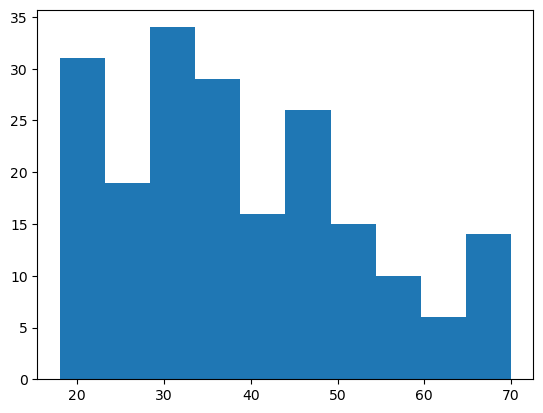

In [6]:
plt.hist(df['Age'])

(array([24., 22., 28., 38., 30., 36.,  8.,  6.,  4.,  4.]),
 array([ 15. ,  27.2,  39.4,  51.6,  63.8,  76. ,  88.2, 100.4, 112.6,
        124.8, 137. ]),
 <BarContainer object of 10 artists>)

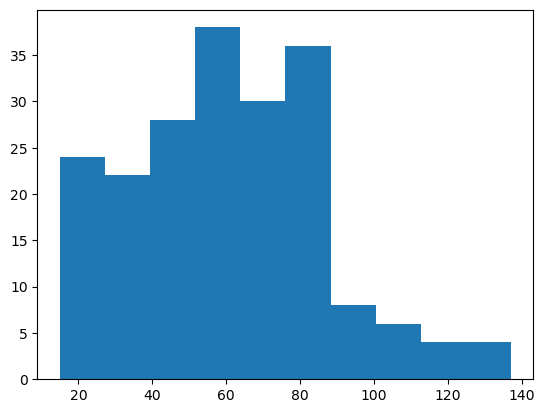

In [7]:
plt.hist(df['Annual Income (k$)'])

(array([16., 20., 10., 17., 35., 37., 11., 24., 14., 16.]),
 array([ 1. , 10.8, 20.6, 30.4, 40.2, 50. , 59.8, 69.6, 79.4, 89.2, 99. ]),
 <BarContainer object of 10 artists>)

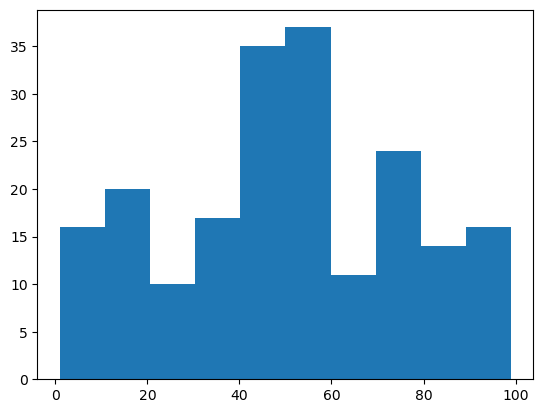

In [8]:
plt.hist(df['Spending Score (1-100)'])

In [9]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'GenderID']

In [10]:
X = df[features]

In [11]:
scaler = StandardScaler()

In [12]:
X_scale = scaler.fit_transform(X)

In [13]:
error_rate = []
k_range = range(1 ,21)

In [14]:
for i in k_range:
    k_means = KMeans(n_clusters=i, random_state=42)
    k_means.fit(X_scale)
    error_rate.append(k_means.inertia_)

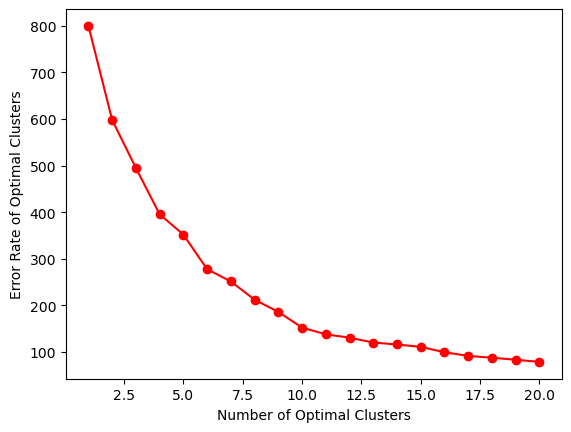

In [15]:
plt.plot(k_range, error_rate, c='red', marker='o')
plt.xlabel('Number of Optimal Clusters')
plt.ylabel('Error Rate of Optimal Clusters')
plt.show()

In [16]:
k = 5
model = KMeans(n_clusters=k, random_state=42)
clusters = model.fit_predict(X_scale)

In [17]:
show_labels = model.labels_

In [18]:
show_labels

array([2, 2, 4, 4, 4, 4, 4, 4, 0, 4, 0, 4, 0, 4, 0, 2, 4, 2, 0, 4, 2, 2,
       0, 2, 0, 2, 0, 2, 4, 4, 0, 4, 0, 2, 0, 4, 0, 4, 4, 4, 0, 2, 0, 4,
       0, 4, 0, 4, 4, 4, 0, 2, 4, 0, 0, 0, 0, 0, 4, 0, 0, 2, 0, 0, 0, 2,
       4, 0, 2, 4, 0, 0, 0, 0, 0, 2, 3, 2, 4, 0, 0, 2, 0, 3, 4, 0, 0, 4,
       4, 0, 0, 2, 0, 3, 4, 2, 3, 4, 0, 2, 4, 3, 0, 2, 0, 4, 0, 0, 0, 0,
       0, 4, 3, 2, 4, 4, 0, 3, 3, 3, 2, 3, 3, 2, 3, 3, 1, 2, 1, 2, 1, 2,
       3, 3, 1, 3, 3, 2, 1, 3, 0, 2, 3, 3, 1, 2, 1, 3, 3, 2, 1, 2, 3, 3,
       3, 3, 1, 3, 1, 3, 3, 3, 1, 3, 1, 3, 1, 3, 3, 2, 1, 2, 1, 2, 3, 3,
       1, 2, 1, 2, 3, 3, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 1, 3, 3, 3, 3, 2,
       1, 2], dtype=int32)

In [19]:
ss = silhouette_score(X_scale, show_labels)
ss

0.2719102346618833

In [20]:
df['clusters'] = clusters

In [25]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'GenderID', 'clusters'],
      dtype='object')

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

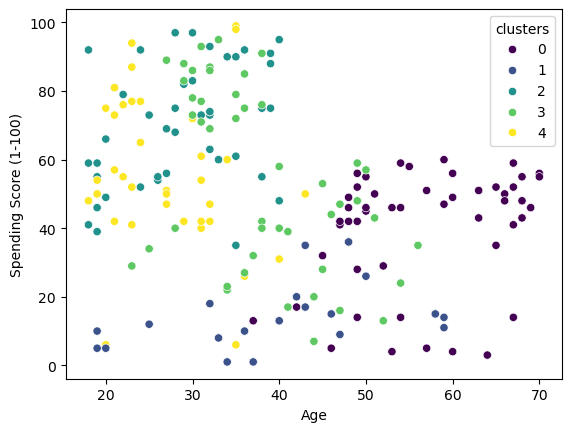

In [26]:
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', hue='clusters', palette='viridis')

In [23]:
pair_plot = df

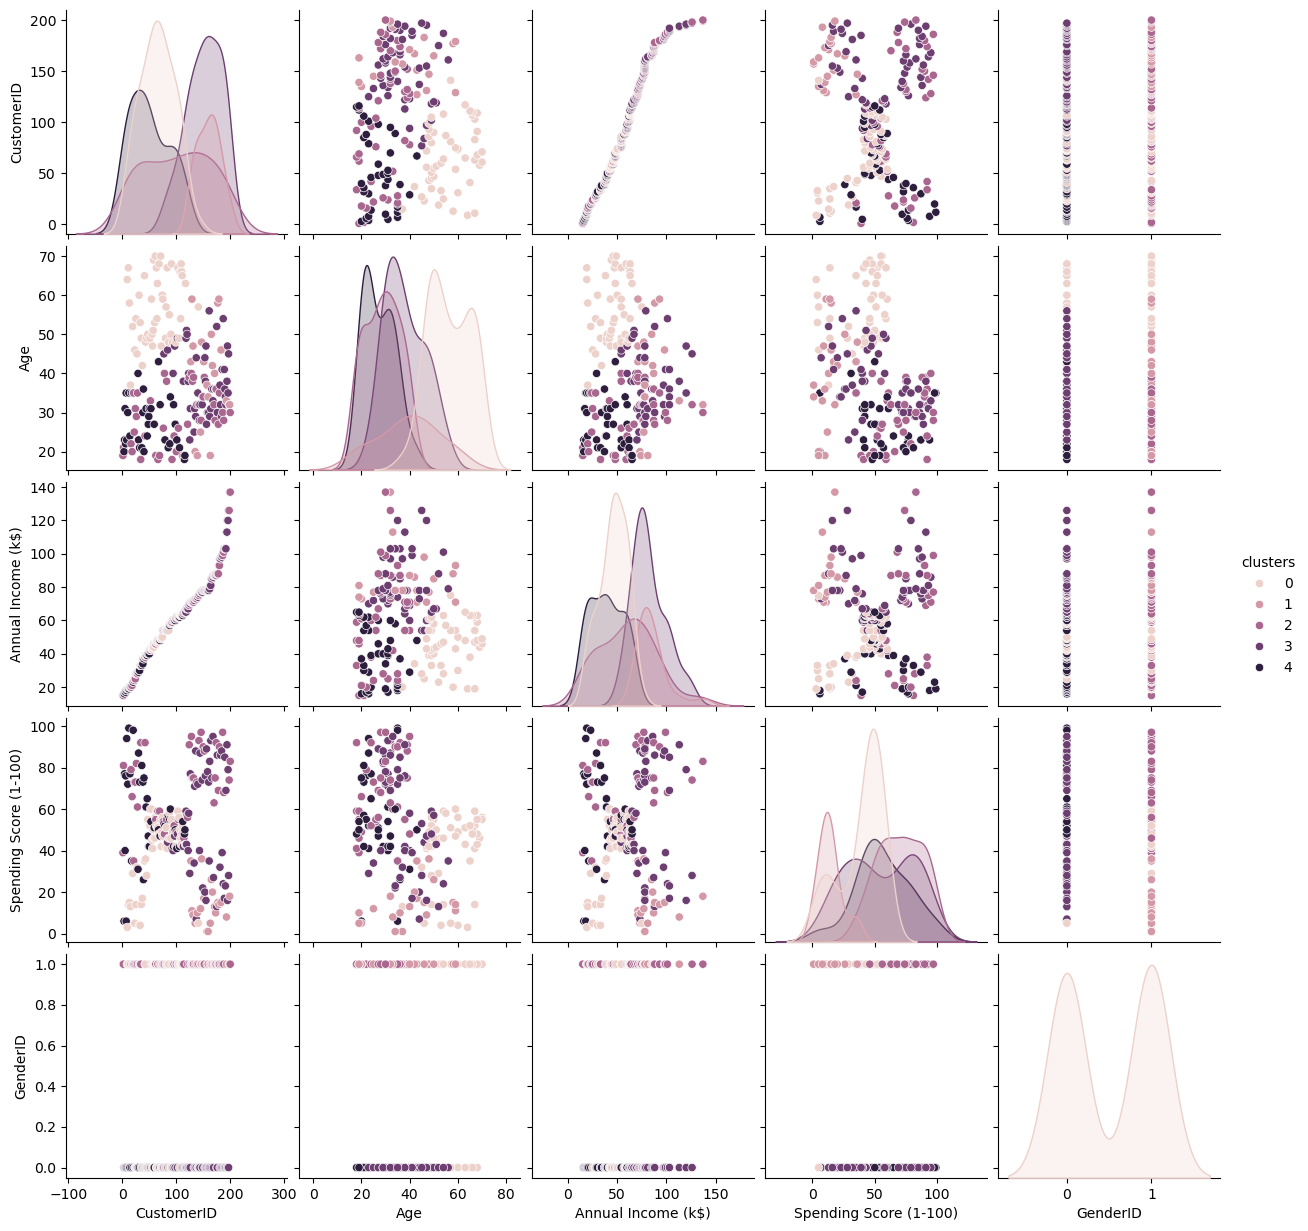

In [24]:
sns.pairplot(
    pair_plot, # copied dataframe
    hue='clusters' # copied dataframe clusters column
)

In [28]:
input_data = {
    'Age': [20, 30, 40], 
    'Annual Income (k$)': [40, 30, 50], 
    'Spending Score (1-100)': [45, 65, 77], 
    'GenderID': [0, 1, 0]
}

In [29]:
X_new = pd.DataFrame(input_data)

In [30]:
X_new_scale = scaler.transform(X_new)

In [31]:
pred = model.predict(X_new_scale)

In [33]:
X_new['Clusters'] = pred

In [35]:
X_new['GenderID'] = encoder.inverse_transform(X_new['GenderID'])

In [36]:
X_new

,Age,Annual Income (k$),Spending Score (1-100),GenderID,Clusters
0,20,40,45,Female,4
1,30,30,65,Male,2
2,40,50,77,Female,4
